# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [5]:
#Carregue aqui a base de dados
df = pd.read_csv("/content/base_logistica_entregas.csv")
df

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
...,...,...,...,...,...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [6]:
# Espaço para resolver a Parte A

# Resposta exercício 1
df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [7]:
# Resposta exercício 2
df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [8]:
# Resposta exercício 3
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [9]:
# Resposta exercício 4
df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [10]:
# Resposta exercício 5
df.isnull().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [11]:
# Resposta exercício 6
df.shape

(200, 11)

In [12]:
# Resposta exercício 7
'''
A variável alvo é o tempo de entrega minímo.
'''

'\nA variável alvo é o tempo de entrega minímo.\n'

In [13]:
# Resposta exercício 8
'''
As variáveis que parecem boas apenas visualizando os dados são: distancia_km,
trafego, clima, regiao e atrasou.
'''

'\nAs variáveis que parecem boas apenas visualizando os dados são: distancia_km,\ntrafego, clima, regiao e atrasou.\n'

In [14]:
# Resposta exercício 9
'''
As variáveis categóricas são: trafego, clima, tipo_entrega, regiao e atrasou.
'''

'\nAs variáveis categóricas são: trafego, clima, tipo_entrega, regiao e atrasou.\n'

In [15]:
# Resposta exercício 10
'''
Porque a regressão linear só funciona com variaveis numéricas.
'''

'\nPorque a regressão linear só funciona com variaveis numéricas.\n'

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [16]:
# Espaço para resolver a Parte B

# Resposta exercício 11
df['tempo_entrega_min'].mean()

np.float64(158.355)

In [17]:
# Resposta exercício 12
df['tempo_entrega_min'].median()

158.5

In [18]:
# Resposta exercício 13
df['tempo_entrega_min'].std()

49.45043683849101

In [19]:
# Resposta exercício 14
df['tempo_entrega_min'].min()

44

In [20]:
df['tempo_entrega_min'].max()

286

In [21]:
# Resposta exercício 15
np.percentile(df['tempo_entrega_min'], [25,50,75])

array([126.  , 158.5 , 189.25])

In [22]:
# Resposta exercício 16
'''
A média e a mediana do tempo de entrega estão bem parecidas por isso podemos
dizer que os dados são simétricos.
'''

'\nA média e a mediana do tempo de entrega estão bem parecidas por isso podemos\ndizer que os dados são simétricos.\n'

In [23]:
# Resposta exercício 17
'''
Sim, existe uma variação grande no tempo quando observamos o desvio padrão da
coluna.
'''

'\nSim, existe uma variação grande no tempo quando observamos o desvio padrão da\ncoluna.\n'

<Axes: ylabel='tempo_entrega_min'>

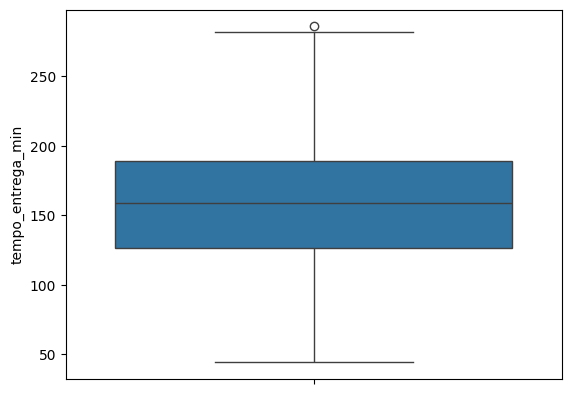

In [24]:
# Resposta exercício 18
sns.boxplot(df['tempo_entrega_min'])

In [25]:
# Resposta exercício 19
df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

,tempo_entrega_min
tipo_entrega,
expressa,149.894737
normal,161.727273


In [26]:
# Resposta exercício 20
df.groupby('trafego')['tempo_entrega_min'].mean()

,tempo_entrega_min
trafego,
alto,188.075000
baixo,135.119403
medio,162.311828


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

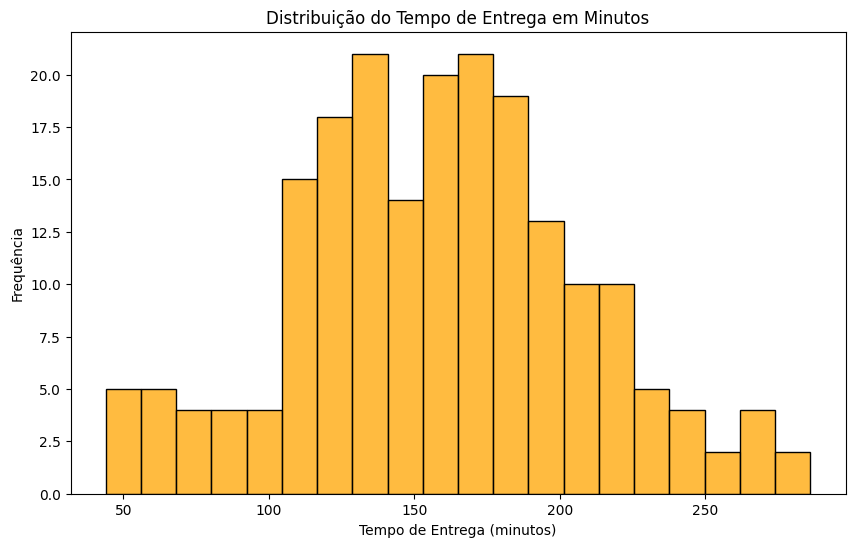

In [27]:
# Espaço para resolver a Parte C

# # Resposta exercício 21
plt.figure(figsize=(10, 6))
sns.histplot(df['tempo_entrega_min'], bins=20, color='orange')
plt.title('Distribuição do Tempo de Entrega em Minutos')
plt.xlabel('Tempo de Entrega (minutos)')
plt.ylabel('Frequência')
plt.show()

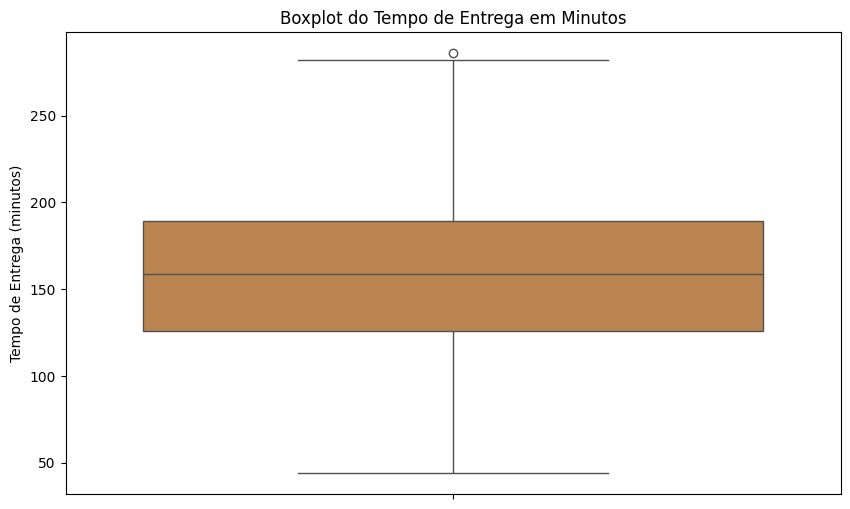

In [28]:
# Resposta exercício 22
plt.figure(figsize=(10,6))
sns.boxplot(df['tempo_entrega_min'], color='peru')
plt.title('Boxplot do Tempo de Entrega em Minutos')
plt.ylabel('Tempo de Entrega (minutos)')
plt.show()

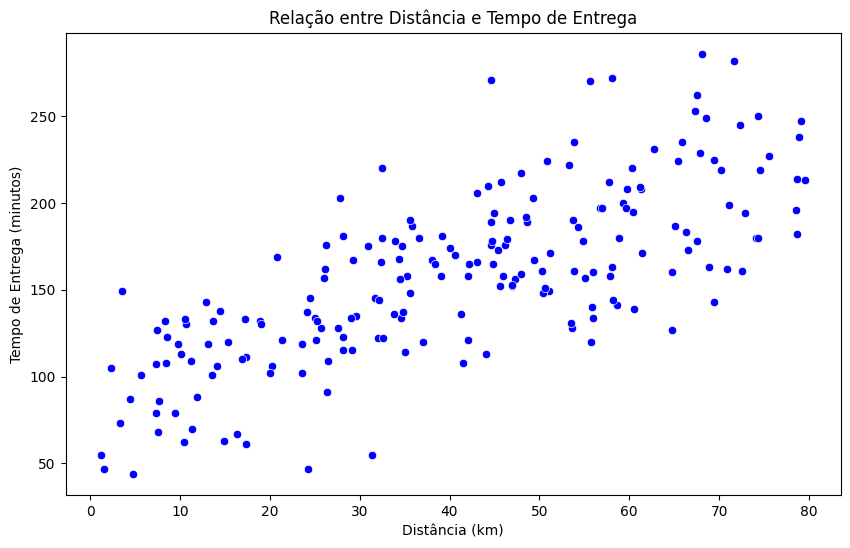

In [29]:
# Resposta exercício 23
plt.figure(figsize=(10,6))
sns.scatterplot(data = df, x="distancia_km", y="tempo_entrega_min", color='blue')
plt.title('Relação entre Distância e Tempo de Entrega')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (minutos)')
plt.show()

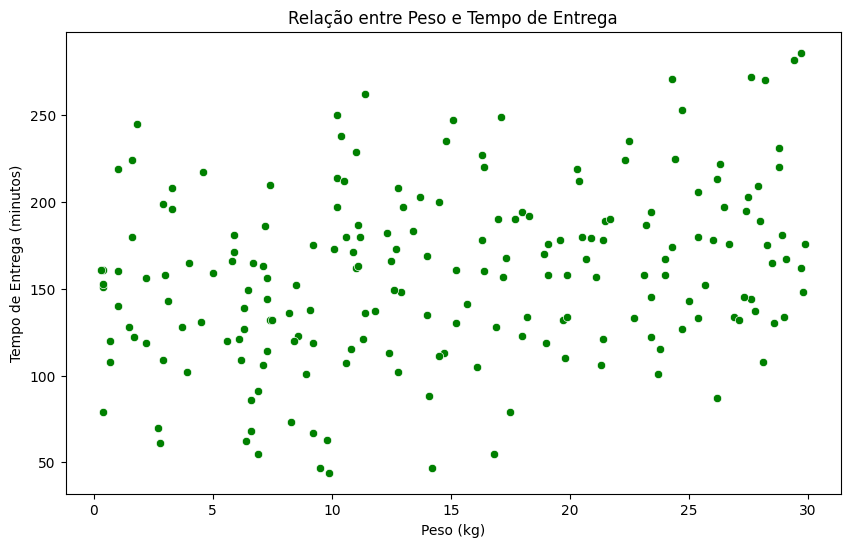

In [30]:
# Resposta exercício 24
plt.figure(figsize=(10,6))
sns.scatterplot(data = df, x="peso_kg", y="tempo_entrega_min", color='green')
plt.title('Relação entre Peso e Tempo de Entrega')
plt.xlabel('Peso (kg)')
plt.ylabel('Tempo de Entrega (minutos)')
plt.show()

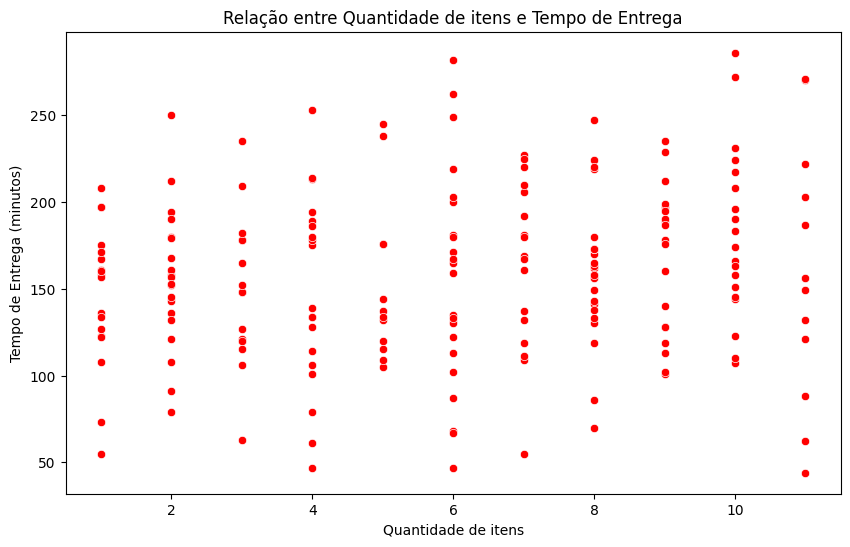

In [31]:
# Resposta exercício 25
plt.figure(figsize=(10,6))
sns.scatterplot(data = df, x="qtd_itens", y="tempo_entrega_min", color='red')
plt.title('Relação entre Quantidade de itens e Tempo de Entrega')
plt.xlabel('Quantidade de itens')
plt.ylabel('Tempo de Entrega (minutos)')
plt.show()

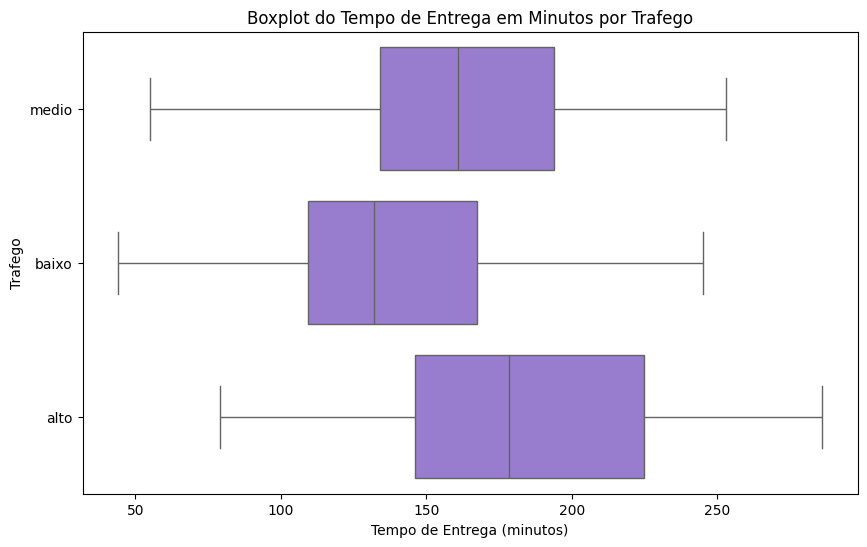

In [32]:
# Resposta exercício 26
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='tempo_entrega_min', y='trafego', color='mediumpurple')
plt.title('Boxplot do Tempo de Entrega em Minutos por Trafego')
plt.xlabel('Tempo de Entrega (minutos)')
plt.ylabel('Trafego')
plt.show()

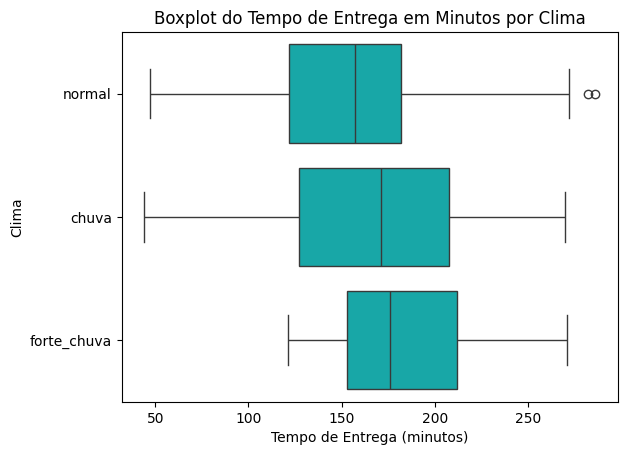

In [33]:
# Resposta exercício 27
sns.boxplot(data=df, x='tempo_entrega_min', y='clima', color='c')
plt.title('Boxplot do Tempo de Entrega em Minutos por Clima')
plt.xlabel('Tempo de Entrega (minutos)')
plt.ylabel('Clima')
plt.show()

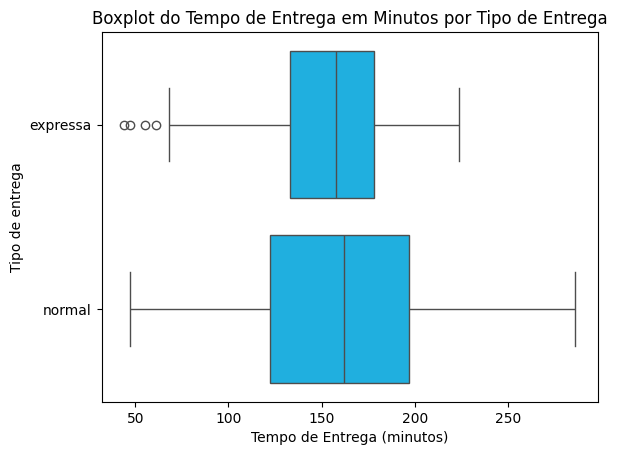

In [34]:
# Resposta exercício 28
sns.boxplot(data=df, x='tempo_entrega_min', y='tipo_entrega', color='deepskyblue')
plt.title('Boxplot do Tempo de Entrega em Minutos por Tipo de Entrega')
plt.xlabel('Tempo de Entrega (minutos)')
plt.ylabel('Tipo de entrega')
plt.show()

In [35]:
# Resposta exercício 29
'''
Visualmente a variável distancia_km é a que parece estar mais relacionada com o
tempo de entrega
'''

'\nVisualmente a variável distancia_km é a que parece estar mais relacionada com o\ntempo de entrega\n'

In [36]:
# Resposta exercício 30
'''
Sim, parece ter uma relação linear entre as duas variáveis
'''

'\nSim, parece ter uma relação linear entre as duas variáveis\n'

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [37]:
# Espaço para resolver a Parte D
# Resposta exercício 31
df_numerico = df[['id_pedido','distancia_km','peso_kg','qtd_itens','valor_pedido','tempo_entrega_min']]
df_numerico

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.0,16.4,9,2158.92,160
1,2,23.6,2.2,9,1431.91,119
2,3,18.9,19.7,5,464.30,132
3,4,44.6,29.9,5,1290.63,176
4,5,57.8,23.1,1,1899.66,158
...,...,...,...,...,...,...
195,196,51.2,10.9,1,1897.47,171
196,197,3.5,6.5,11,1356.59,149
197,198,59.8,12.8,10,2247.45,208
198,199,38.4,6.7,3,2369.26,165


In [38]:
# Resposta exercício 32
matriz_correlacao = df_numerico.corr()
matriz_correlacao

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
id_pedido,1.000000,-0.010864,0.020593,-0.034910,0.036968,0.014440
distancia_km,-0.010864,1.000000,-0.020853,-0.039094,-0.073556,0.743120
peso_kg,0.020593,-0.020853,1.000000,0.016054,-0.037019,0.280642
qtd_itens,-0.034910,-0.039094,0.016054,1.000000,0.132516,0.156666
valor_pedido,0.036968,-0.073556,-0.037019,0.132516,1.000000,-0.045193
tempo_entrega_min,0.014440,0.743120,0.280642,0.156666,-0.045193,1.000000


<Axes: >

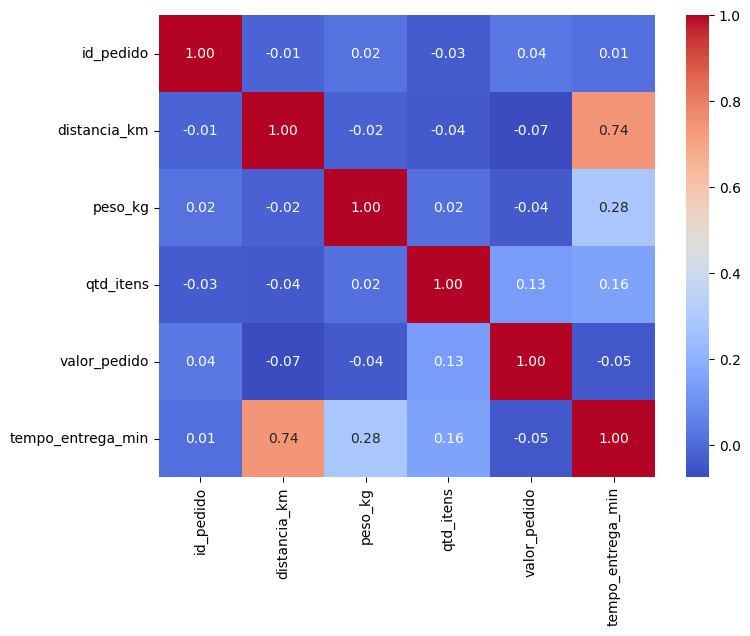

In [39]:
# Resposta exercício 33
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f")

In [40]:
# Resposta exercício 34
'''
A variável que tem mais correlação positiva com o tempo de entrega mínimo é
a distancia em km.
'''

'\nA variável que tem mais correlação positiva com o tempo de entrega mínimo é\na distancia em km.\n'

In [41]:
# Resposta exercício 35
'''
A variável que tem menor relação com o tempo de entrega mínimo é
o id do pedido.
'''

'\nA variável que tem menor relação com o tempo de entrega mínimo é\no id do pedido.\n'

In [42]:
# Resposta exercício 36


In [43]:
# Resposta exercício 37
'''
No caso da variável valor_pedido que possue uma correlação negativa em relação
a variável tempo_entrega_min, essa primeira variável não deveria serr usada num modelo
de regrssão linear por conta dessa baixa correlação, mas nada impede de usá-la e
fazer uma comparação entre modelos.
'''

'\nNo caso da variável valor_pedido que possue uma correlação negativa em relação\na variável tempo_entrega_min, essa primeira variável não deveria serr usada num modelo\nde regrssão linear por conta dessa baixa correlação, mas nada impede de usá-la e\nfazer uma comparação entre modelos.\n'

In [44]:
# Resposta exercício 38
'''
Sim, a variável distancia é importante para o modelo e para a variável tempo
de entrega minimo
'''

'\nSim, a variável distancia é importante para o modelo e para a variável tempo\nde entrega minimo\n'

In [45]:
# Resposta exercício 39
'''
Sim, a variável peso_kg parece importante apesar de não ter uma alta correlação
com a variável tempo de entrega minima
'''

'\nSim, a variável peso_kg parece importante apesar de não ter uma alta correlação\ncom a variável tempo de entrega minima\n'

In [46]:
# Resposta exercício 40
'''
Para um modelo inicial eu escolheria as variaveis peso_kg, distancia_km e
qtd_itens
'''

'\nPara um modelo inicial eu escolheria as variaveis peso_kg, distancia_km e\nqtd_itens\n'

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [47]:
# Espaço para resolver a Parte E
# Resposta exercício 41
X = df['distancia_km'].values.reshape(-1,1)
X

array([[56. ],
       [23.6],
       [18.9],
       [44.6],
       [57.8],
       [34.4],
       [78.5],
       [55.1],
       [39. ],
       [32. ],
       [28.1],
       [58.6],
       [35.6],
       [ 5.7],
       [32.4],
       [59.3],
       [15.4],
       [14.9],
       [43. ],
       [43. ],
       [51.1],
       [68.1],
       [58.2],
       [49.3],
       [58.1],
       [26.5],
       [29.6],
       [19. ],
       [24.2],
       [50.8],
       [ 8.3],
       [35.3],
       [35. ],
       [40. ],
       [34.6],
       [25.7],
       [34.7],
       [71.6],
       [75.6],
       [40.6],
       [50.3],
       [10.1],
       [26.1],
       [33.8],
       [69.4],
       [20.8],
       [39.2],
       [78.9],
       [42. ],
       [49.4],
       [10.5],
       [66.3],
       [48.6],
       [44.1],
       [28.1],
       [25. ],
       [33.9],
       [54.8],
       [70.2],
       [41.3],
       [53.9],
       [47.3],
       [50.4],
       [54.3],
       [67.5],
       [ 7.6],
       [61

In [48]:
# Resposta exercício 42
y = df['tempo_entrega_min']
y

,tempo_entrega_min
0,160
1,119
2,132
3,176
4,158
...,...
195,171
196,149
197,208
198,165


In [49]:
# Resposta exercício 43
modelo_regre = LinearRegression()

modelo_regre.fit(X,y)

LinearRegression()

In [50]:
# Resposta exercício 44
# coeficiente angular
modelo_regre.coef_

array([1.74604322])

In [51]:
# Resposta exercício 45
# intercepto
modelo_regre.intercept_

np.float64(87.19064329209331)

In [52]:
# Resposta exercício 46
'''
O coeficiente angular foi de aproximadamente 1.74, isso quer dizer que a cada km
percorrido o tempo de entrega prevista aumenta em 1.74.
'''

'\nO coeficiente angular foi de aproximadamente 1.74, isso quer dizer que a cada km\npercorrido o tempo de entrega prevista aumenta em 1.74.\n'

In [53]:
# Resposta exercício 47
y_pred = modelo_regre.predict(X)
y_pred

array([184.96906384, 128.39726338, 120.19086023, 165.06417109,
       188.11194165, 147.2545302 , 224.25503639, 183.39762494,
       155.28632903, 143.06402646, 136.25445789, 189.50877623,
       149.34978207,  97.14308967, 143.76244375, 190.73100648,
       114.07970894, 113.20668733, 162.27050193, 162.27050193,
       176.41345205, 206.09618686, 188.81035894, 173.27057424,
       188.63575461, 133.46078873, 138.87352273, 120.36546455,
       129.44488932, 175.88963908, 101.68280205, 148.8259691 ,
       148.30215614, 157.03237226, 147.60373885, 132.06395415,
       147.77834317, 212.20733814, 219.19151104, 158.07999819,
       175.01661747, 104.82567986, 132.76237144, 146.20690427,
       208.36604305, 123.50834235, 155.63553768, 224.95345368,
       160.52445871, 173.44517856, 105.52409715, 202.95330905,
       172.04834399, 164.19114948, 136.25445789, 130.8417239 ,
       146.38150859, 182.87381197, 209.76287763, 159.30222845,
       181.30237307, 169.77848779, 175.19122179, 182.00

In [54]:
# Resposta do exercício 48
df_previsto = pd.DataFrame({
    "distancia" : df['distancia_km'],
    "tempo_real": y,
    "tempo_previsto": y_pred,
    "erro": y - y_pred
})

df_previsto

,distancia,tempo_real,tempo_previsto,erro
0,56.0,160,184.969064,-24.969064
1,23.6,119,128.397263,-9.397263
2,18.9,132,120.190860,11.809140
3,44.6,176,165.064171,10.935829
4,57.8,158,188.111942,-30.111942
...,...,...,...,...
195,51.2,171,176.588056,-5.588056
196,3.5,149,93.301795,55.698205
197,59.8,208,191.604028,16.395972
198,38.4,165,154.238703,10.761297


In [55]:
# Resposta exercício 49
mae_sklearn = mean_absolute_error(y, y_pred)
mse_sklearn = mean_squared_error(y, y_pred)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y, y_pred)

mae_sklearn, mse_sklearn, rmse_sklearn, r2_sklearn

(26.284422029631706,
 1089.4844339051501,
 np.float64(33.00733909155887),
 0.5522272255900884)

In [56]:
# Resposta exercício 50
'''
O MAE foi de 26.28 então o modelo errou 26.28 pontos.
O RMSE: em média o modelo está errando aproximadamente 33 minutos do tempo
de entrega.
Já o R2 foi de 0.55, que o modelo explica 55% da variação dos dados
'''

'\nO MAE foi de 26.28 então o modelo errou 26.28 pontos.\nO RMSE: em média o modelo está errando aproximadamente 33 minutos do tempo\nde entrega.\nJá o R2 foi de 0.55, que o modelo explica 55% da variação dos dados\n'

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

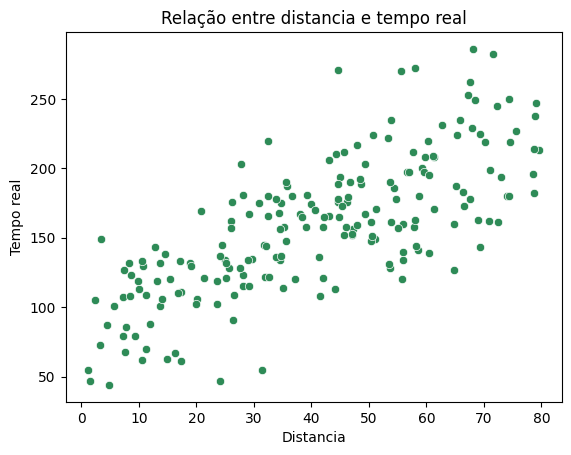

In [57]:
# Espaço para resolver a Parte F

# Resposta do exercício 51
sns.scatterplot(data = df_previsto, x="distancia", y="tempo_real", color='seagreen')
plt.title('Relação entre distancia e tempo real')
plt.xlabel('Distancia')
plt.ylabel('Tempo real')
plt.show()

/tmp/ipykernel_25493/3929378539.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


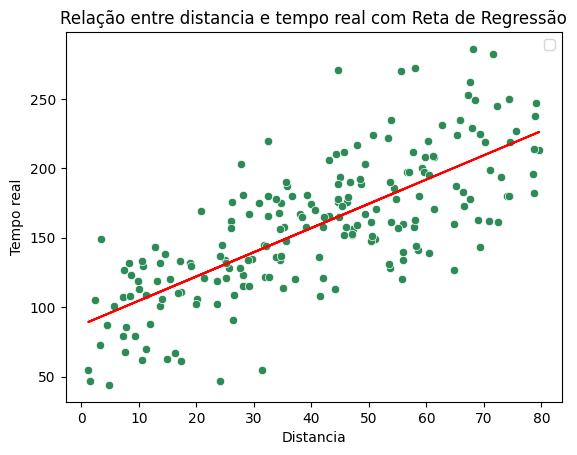

In [58]:
# Resposta do exercício 52
sns.scatterplot(data = df_previsto, x="distancia", y="tempo_real", color='seagreen')
plt.plot(df_previsto['distancia'], df_previsto['tempo_previsto'], color='red')
plt.title('Relação entre distancia e tempo real com Reta de Regressão')
plt.xlabel('Distancia')
plt.ylabel('Tempo real')
plt.legend()
plt.show()

In [59]:
# Resposta do exercício 53
'''
O modelo parece capturar a tendência geral, onde o tempo de entrega aumenta com
a distância. No entanto, muitos pontos estão distantes da reta, o que indica que
a distância sozinha não explica toda a variabilidade do tempo de entrega.
'''

'\nO modelo parece capturar a tendência geral, onde o tempo de entrega aumenta com\na distância. No entanto, muitos pontos estão distantes da reta, o que indica que\na distância sozinha não explica toda a variabilidade do tempo de entrega.\n'

In [60]:
# Resposta do exercício 54
'''
Sim, existe varios pontos distantes da reta.
'''

'\nSim, existe varios pontos distantes da reta.\n'

In [61]:
# Resposta do exercício 55
'''
Esses pontos representam os dados das colunas
'''

'\nEsses pontos representam os dados das colunas\n'

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [62]:
# Espaço para resolver a Parte G

# Resposta do exercício 56
modelo_regre.predict(np.array([5]).reshape(-1, 1))

array([95.92085941])

In [63]:
# Resposta do exercício 57
modelo_regre.predict(np.array([20]).reshape(-1, 1))

array([122.11150777])

In [64]:
# Resposta do exercício 58
modelo_regre.predict(np.array([60]).reshape(-1, 1))

array([191.95323674])

In [65]:
# Resposta do exercício 59
'''
As previsões não fazem sentido porque é muito tempo para pouca distancia
'''

'\nAs previsões não fazem sentido porque é muito tempo para pouca distancia\n'

In [66]:
# Resposta do exercício 60
'''

'''

'\n\n'

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [67]:
# Exemplo inicial para a Parte H

# Resposta do exercício 61
df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

In [68]:
# Resposta do exercício 62
df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,False,True,False,True,False,False,False


In [69]:
# Resposta do exercício 63
'''
O get_dummies() é uma função do Pandas usada para converter variáveis categoricas
em dummy. Isso transforma a coluna categórica em multiplas colunas de True ou False.
'''

'\nO get_dummies() é uma função do Pandas usada para converter variáveis categoricas\nem dummy. Isso transforma a coluna categórica em multiplas colunas de True ou False.\n'

In [70]:
# Resposta do exercício 64
'''
O drop_first é um parametro usado para converter variaveis categoricas em dummy
removendo a primeira aparição de cada categoria.
'''

'\nO drop_first é um parametro usado para converter variaveis categoricas em dummy\nremovendo a primeira aparição de cada categoria.\n'

In [71]:
# Resposta do exercício 65
'''
Foram criadas as colunas 'trafego_baixo', 'trafego_medio', 'clima_forte_chuva',
'clima_normal', 'tipo_entrega_normal', 'regiao_centro' e 'regiao_zona_rural'.
'''

"\nForam criadas as colunas 'trafego_baixo', 'trafego_medio', 'clima_forte_chuva',\n'clima_normal', 'tipo_entrega_normal', 'regiao_centro' e 'regiao_zona_rural'.\n"

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [72]:
# Espaço para resolver a Parte I

# Resposta exercício 66
new_X = df_modelo[['distancia_km','peso_kg','qtd_itens', 'valor_pedido','trafego_baixo','trafego_medio','clima_forte_chuva','clima_normal','tipo_entrega_normal','regiao_centro','regiao_zona_rural']]

In [74]:
# Resposta exercício 67
new_y = df_modelo['tempo_entrega_min']

In [75]:
# Resposta exercício 68
modelo_multi = LinearRegression()
modelo_multi.fit(new_X, new_y)

LinearRegression()

In [76]:
# Resposta exercício 69
pred_multi = modelo_multi.predict(new_X)

In [78]:
# Resposta exercício 70
mae_multi = mean_absolute_error(new_y, pred_multi)
mae_multi

14.479818301722025

In [79]:
# Resposta exercício 71
rmse_multi = np.sqrt(mean_squared_error(new_y, pred_multi))
rmse_multi

np.float64(17.584048754061453)

In [80]:
# Resposta exercício 72
r2_multi = r2_score(new_y, pred_multi)
r2_multi

0.872920817369726

In [ ]:
# Resposta exercício 73
'''
Comparando esse modelo multiplo com o modelo simples podemos perceber que o modelo
múltiplo apresentou desempenho melhor em todas as métricas.
'''

In [ ]:
# Resposta exercício 74
'''
Sim, o modelo múltiplo melhorou
'''

In [ ]:
# Resposta exercício 75
'''
As variaveis que parecem mais importantes são a distancia, clima normal, clima chuva forte,
regiao centro e regiao zona rural.
'''

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [81]:
# Espaço para resolver a Parte J

# Resposta exercício 76
df_multiplo = pd.DataFrame({
    "variavel" : new_X.columns,
    "coeficientes": modelo_multi.coef_
})
df_multiplo

,variavel,coeficientes
0,distancia_km,1.801969
1,peso_kg,1.443045
2,qtd_itens,2.557247
3,valor_pedido,0.000152
4,trafego_baixo,-35.000253
5,trafego_medio,-17.819863
6,clima_forte_chuva,28.839053
7,clima_normal,-12.477173
8,tipo_entrega_normal,25.284407
9,regiao_centro,-11.643316


In [85]:
# Resposta exercício 77
df_multiplo.sort_values(by='coeficientes', ascending=False)

,variavel,coeficientes
6,clima_forte_chuva,28.839053
8,tipo_entrega_normal,25.284407
10,regiao_zona_rural,14.674497
2,qtd_itens,2.557247
0,distancia_km,1.801969
1,peso_kg,1.443045
3,valor_pedido,0.000152
9,regiao_centro,-11.643316
7,clima_normal,-12.477173
5,trafego_medio,-17.819863


In [ ]:
# Resposta exercício 78
'''
Os coeficientes que aumentam com o tempo previsto são das variaveis clima_forte_chuva,
tipo_entrega_normal e regiao_zona_rural.
'''

In [ ]:
# Resposta exercício 79
'''
Os coeficientes que diminuem com o tempo previsto são das variaveis trafego_baixo,
trafego_medio e clima_normal.
'''

In [ ]:
# Resposta exercício 80
'''
Analisando a variável distancia_km vemos que o coeficiente aumenta em 1.801969 unidades
o valor previsto.
'''

In [ ]:
# Resposta exercício 81
'''
Analisando a variável tipo_entrega_expressa vemos que o coeficiente aumenta
'''

In [ ]:
# Resposta exercício 82
'''
Analisando a variável trafego_alto vemos que o coeficiente

'''

In [ ]:
# Resposta exercício 83
'''
Quando ocorre forte chuva, o valor previsto da variável alvo aumenta, em média,
cerca de 28.84 unidades, mantendo as outras variáveis constantes.
'''

In [ ]:
# Resposta exercício 84
'''
Sim, os sinais dos coeficientes fazem sentido
'''

In [ ]:
# Resposta exercício 85
'''
Um coeficiente estranho é aquele que parece não fazer sentido prático para
aquela variável e para o problema.
'''

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [ ]:
# Espaço para resolver a Parte K

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [ ]:
# Espaço para resolver a Parte L

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.